In [2]:
import pandas as pd

# Load datasets
activity = pd.read_csv("../data/FitbitActivity.csv")
sleep = pd.read_csv("../data/FitbitSleep.csv")
survey = pd.read_csv("../data/BasicSurvey.csv")

# Quick inspection
print("Activity shape:", activity.shape)
print("Sleep shape:", sleep.shape)
print("Survey shape:", survey.shape)

C:\Users\yodit\AppData\Local\Temp\ipykernel_34688\3334393625.py:6: DtypeWarning: Columns (0: prescriptiondrugabuse3rc_1, 1: mjeset3_1, 2: mjesubset3_1, 3: recreationaldrugs3rc_2, 4: prescriptiondrugabuse1rc_2, 5: prescriptiondrugabuse2rc_2, 6: mjeset2_3, 7: mjesubset2_3, 8: recreationaldrugs2rc_3, 9: recreationaldrugs3rc_3, 10: prescriptiondrugabuse2rc_3, 11: prescriptiondrugabuse3rc_3, 12: mjeset3_4, 13: mjesubset3_4, 14: disability3rca_4, 15: disability3rcb_4, 16: disability4rca_4, 17: disability4rcb_4, 18: disability5rca_4, 19: disability5rcb_4, 20: sleepdisorderrc_4, 21: recreationaldrugs2rc_4, 22: prescriptiondrugabuse1rc_4, 23: studyAbroad_5_5, 24: studyAbroadF_Other_5, 25: mjeset3_5, 26: mjesubset3_5, 27: vegan_5, 28: disability3rca_5, 29: disability3rcb_5, 30: undiagall3rca_5, 31: undiagall3rcb_5, 32: recreationaldrugs3rc_5, 33: prescriptiondrugabuse1rc_5, 34: prescriptiondrugabuse2rc_5, 35: prescriptiondrugabuse3rc_5, 36: studyAbroadF_5_6, 37: mjeset3_6, 38: mjesubset3_6, 39: 

Activity shape: (357827, 19)
Sleep shape: (333708, 10)
Survey shape: (722, 3027)


In [3]:
survey.columns[:50]

Index(['egoid', 'Tier', 'StudyStatus', 'RegionUS', 'US', 'StartDate_1',
       'EndDate_1', 'gender_1', 'hs_1', 'hssex_1', 'hsgrade_1', 'apcourses_1',
       'apexams_1', 'degreeintent_1', 'major1rc_1', 'major2rc_1', 'hrswork_1',
       'hsclub1rc_1', 'hsclub2rc_1', 'hsclub3rc_1', 'hsclub4rc_1',
       'hsclub5rc_1', 'relativeND_1', 'parentND_1', 'grandparentND_1',
       'siblingND_1', 'uncleND_1', 'cousinND_1', 'otherrelativeND_1',
       'ndfirst_1', 'momdec_1', 'momusa_1', 'daddec_1', 'dadusa_1',
       'madaddec_1', 'madadusa_1', 'mamomdec_1', 'mamomusa_1', 'padaddec_1',
       'padadusa_1', 'pamomdec_1', 'pamomusa_1', 'parentstatus_1', 'dadage_1',
       'momage_1', 'yrdadborn_1', 'yrdaddec_1', 'yrmomborn_1', 'yrmomdec_1',
       'numbros_1'],
      dtype='str')

In [4]:
survey.filter(like="Stress").columns

Index(['Stress_1_4', 'Stress_2_4', 'Stress_3_4', 'Stress_4_4', 'Stress_5_4',
       'Stress_6_4', 'Stress_7_4', 'Stress_8_4', 'Stress_9_4', 'Stress_10_4',
       'Stress_4', 'Stress_1_5', 'Stress_2_5', 'Stress_3_5', 'Stress_4_5',
       'Stress_5_5', 'Stress_6_5', 'Stress_7_5', 'Stress_8_5', 'Stress_9_5',
       'Stress_10_5', 'Stress_5', 'Stress_1_6', 'Stress_2_6', 'Stress_3_6',
       'Stress_4_6', 'Stress_5_6', 'Stress_6_6', 'Stress_7_6', 'Stress_8_6',
       'Stress_9_6', 'Stress_10_6', 'Stress_6', 'Stress_1_8', 'Stress_2_8',
       'Stress_3_8', 'Stress_4_8', 'Stress_5_8', 'Stress_6_8', 'Stress_7_8',
       'Stress_8_8', 'Stress_9_8', 'Stress_10_8', 'Stress_8'],
      dtype='str')

In [5]:
activity.columns

Index(['egoid', 'datadate', 'complypercent', 'meanrate', 'sdrate', 'steps',
       'floors', 'sedentaryminutes', 'lightlyactiveminutes',
       'fairlyactiveminutes', 'veryactiveminutes', 'lowrangemins',
       'fatburnmins', 'cardiomins', 'peakmins', 'lowrangecal', 'fatburncal',
       'cardiocal', 'peakcal'],
      dtype='str')

In [6]:
# Standardize column names
activity.columns = activity.columns.str.lower()
sleep.columns = sleep.columns.str.lower()
survey.columns = survey.columns.str.lower()

In [7]:
# Convert date columns to datetime for all three datasets 
activity["datadate"] = pd.to_datetime(activity["datadate"])
sleep["datadate"] = pd.to_datetime(sleep["datadate"])

date_cols = [col for col in survey.columns if col.startswith("startdate_")]

for col in date_cols:
    survey[col] = pd.to_datetime(survey[col], format="%d%b%Y %H:%M:%S", errors="coerce")

In [8]:
# activity.dtypes
# sleep.dtypes
# survey[date_cols].dtypes

In [9]:
# sleep.head()

In [10]:
# check if there are duplicate rows in the sleep data
sleep.groupby(['egoid','datadate']).size().max()

np.int64(10)

In [11]:
# Aggregate multiple sleep sessions per day into one daily summary per participant,
# using weighted average for Efficiency (weighted by minutes asleep)

# First create weighted efficiency numerator
sleep['eff_weighted'] = sleep['efficiency'] * sleep['minsasleep']

sleep_daily = (
    sleep
    .groupby(['egoid','datadate'], as_index=False)
    .agg({
        'timetobed': 'min',
        'timeoutofbed': 'max',
        'bedtimedur': 'sum',
        'minstofallasleep': 'sum',
        'minsafterwakeup': 'sum',
        'minsasleep': 'sum',
        'minsawake': 'sum',
        'eff_weighted': 'sum'
    })
)

# Compute proper daily efficiency
sleep_daily['efficiency'] = (
    sleep_daily['minsasleep'] /
    (sleep_daily['minsasleep'] + sleep_daily['minsawake'])
)

# Drop helper column
sleep_daily = sleep_daily.drop(columns='eff_weighted')

In [12]:
# check if there are duplicate rows in the sleep data
sleep_daily.groupby(['egoid','datadate']).size().max()

np.int64(1)

### activity + sleep = wearable_daily


In [13]:
# Merge activity and sleep
wearable_daily = activity.merge(
    sleep_daily,
    on=['egoid', 'datadate'],
    how='inner'   # keep only days with both
)
wearable_daily.shape

(296778, 27)

In [14]:
wearable_daily.columns

Index(['egoid', 'datadate', 'complypercent', 'meanrate', 'sdrate', 'steps',
       'floors', 'sedentaryminutes', 'lightlyactiveminutes',
       'fairlyactiveminutes', 'veryactiveminutes', 'lowrangemins',
       'fatburnmins', 'cardiomins', 'peakmins', 'lowrangecal', 'fatburncal',
       'cardiocal', 'peakcal', 'timetobed', 'timeoutofbed', 'bedtimedur',
       'minstofallasleep', 'minsafterwakeup', 'minsasleep', 'minsawake',
       'efficiency'],
      dtype='str')

### survey


In [15]:
survey.shape

(722, 3027)

In [16]:
# [c for c in survey.columns if "extra" in c or "agree" in c or "consc" in c or "neuro" in c or "open" in c]

In [17]:
bigfive_cols = [c for c in survey.columns if any(trait in c for trait in [
    "extraversion",
    "agreeableness",
    "conscientiousness",
    "neuroticism",
    "openness"
])]
len(bigfive_cols)

20

In [18]:
survey_selected = survey[['egoid'] + bigfive_cols]
survey_selected.shape

(722, 21)

In [19]:
psqi_cols = [c for c in survey.columns if "psqiglobal" in c or "psqigroup" in c or "psqi_duration" in c]
len(psqi_cols)

17

In [20]:
survey_selected = survey[['egoid'] + bigfive_cols + psqi_cols]
survey_selected.shape

(722, 38)

In [21]:
meq_cols = [c for c in survey.columns if "meqtotal" in c or "meqgroup" in c]
len(meq_cols)

4

In [22]:
survey_selected = survey[['egoid'] + bigfive_cols + psqi_cols + meq_cols]
survey_selected.shape

(722, 42)

In [23]:
scale_cols = [c for c in survey.columns if "scale_" in c and ("selfeff" in c or "selfreg" in c)]
len(scale_cols)

11

In [24]:
survey_selected = survey[['egoid'] + bigfive_cols + psqi_cols + meq_cols + scale_cols]
survey_selected.shape

(722, 53)

In [25]:
# [c for c in survey.columns if "selfesteem_" in c and "_1_" not in c]

In [26]:
[c for c in survey.columns if "esteem" in c and ("scale" in c or "total" in c)]

[]

In [27]:
# [c for c in survey.columns if "selfesteem_" in c and c.endswith("_1")]

In [28]:
survey[['selfesteem_1']].head()

,selfesteem_1
0,42.0
1,39.0
2,47.0
3,37.0
4,32.0


In [29]:
selfesteem_cols = [c for c in survey.columns if c.startswith("selfesteem_") and c.count("_") == 1]
len(selfesteem_cols)

7

In [30]:
survey_selected = survey[['egoid'] + bigfive_cols + psqi_cols + meq_cols + scale_cols + selfesteem_cols]
survey_selected.shape

(722, 60)

In [31]:
# [c for c in survey.columns if "selsa" in c or "lonely" in c]

In [32]:
selsa_cols = [c for c in survey.columns if "selsa_" in c]
len(selsa_cols)

18

In [33]:
survey_selected = survey[['egoid'] + bigfive_cols + psqi_cols + meq_cols + scale_cols + selfesteem_cols + selsa_cols]
survey_selected.shape

(722, 78)

In [34]:
# [c for c in survey.columns if "trust" in c]

In [35]:
trust_cols = [c for c in survey.columns if c.startswith("trust_") and c.count("_") == 1]
len(trust_cols)

6

In [36]:
survey_selected = survey[['egoid'] + bigfive_cols + psqi_cols + meq_cols + scale_cols + selfesteem_cols + selsa_cols + trust_cols]
survey_selected.shape

(722, 84)

In [37]:
# [c for c in survey.columns if "exercise" in c]

In [38]:
exercise_cols = [c for c in survey.columns if c.startswith("exercise") and "scale" not in c and "self" not in c]
# exercise_cols

In [39]:
exercise_cols = [c for c in exercise_cols if "tracking" not in c and "adjust" not in c and "perceivedchange" not in c]
len(exercise_cols)

15

In [40]:
survey_selected = survey_selected.join(survey[exercise_cols])
survey_selected.shape

(722, 99)

In [41]:
# [c for c in survey.columns if "gender" in c or "age" in c or "region" in c]

In [42]:
demo_cols = ['regionus','gender_1','dadage_1','momage_1']
survey_selected = survey_selected.join(survey[demo_cols])
survey_selected.shape

(722, 103)

In [43]:
len(survey_selected.columns)

103

In [44]:
# Rename static demographic columns to remove the wave indicator
static_rename_map = {
    'gender_1': 'gender',
    'dadage_1': 'dadage',
    'momage_1': 'momage'
}
survey_selected = survey_selected.rename(columns=static_rename_map)

# List of static columns that will be duplicated across waves
# 'regionus' is already formatted correctly
static_cols = ['egoid', 'regionus', 'gender', 'dadage', 'momage']
survey_selected.columns

Index(['egoid', 'extraversion_1', 'agreeableness_1', 'conscientiousness_1',
       'neuroticism_1', 'openness_1', 'extraversion_2', 'agreeableness_2',
       'conscientiousness_2', 'neuroticism_2',
       ...
       'exercisealone_6', 'exerciseothers_6', 'exercisealone_7',
       'exerciseothers_7', 'exercisealone_8', 'exerciseothers_8', 'regionus',
       'gender', 'dadage', 'momage'],
      dtype='str', length=103)

In [45]:
# Find all columns that still have an underscore (these are your time-varying wave variables)
wave_cols = [c for c in survey_selected.columns if "_" in c]

# Extract unique base names (stubnames) before the wave number
# We use rsplit('_', 1) to split only on the LAST underscore.
# This ensures a column like 'psqi_duration_1' correctly becomes 'psqi_duration'
stubnames = list(set([c.rsplit('_', 1)[0] for c in wave_cols]))

# Print the list and length to verify we captured everything correctly
print(f"Total unique time-varying features: {len(stubnames)}")
print(sorted(stubnames))

Total unique time-varying features: 21
['agreeableness', 'conscientiousness', 'exercise', 'exercisealone', 'exerciseothers', 'extraversion', 'meqgroup', 'meqtotal', 'neuroticism', 'openness', 'psqi_duration', 'psqiglobal', 'psqigroup', 'selfeff_diet_scale', 'selfeff_exercise_scale', 'selfesteem', 'selfreg_scale', 'selsa_fam', 'selsa_rom', 'selsa_soc', 'trust']


In [46]:
# Perform the wide-to-long reshape (each wave becomes a row instead of a column )
survey_long = pd.wide_to_long(
    survey_selected,
    stubnames=stubnames,
    i='egoid',           # The unique participant identifier
    j='wave',            # The name of the new column we are creating for the wave number
    sep='_',             # The separator between the stubname and the wave number
    suffix=r'\d+'        # Regex indicating the suffix is a digit (e.g., 1 through 8)
).reset_index()          # Flattens 'egoid' and 'wave' back into standard columns

# Sort the dataset chronologically per participant for easier viewing
survey_long = survey_long.sort_values(by=['egoid', 'wave']).reset_index(drop=True)

# Print the new shape and the first few rows to verify
print("New shape:", survey_long.shape)
# survey_long.head()

New shape: (5776, 27)


### survey_long_imputed + wearable_daily = final_dataset


In [47]:
# Check the overall timeline of the study
print(f"Earliest date: {wearable_daily['datadate'].min().date()}")
print(f"Latest date:   {wearable_daily['datadate'].max().date()}")

# Calculate how many days of data we have per participant
days_per_person = wearable_daily.groupby('egoid').size()

print(f"\nParticipant Coverage:")
print(f"Average days per person: {days_per_person.mean():.1f}")
print(f"Fewest days for a person: {days_per_person.min()}")
print(f"Most days for a person:   {days_per_person.max()}")

Earliest date: 2015-07-24
Latest date:   2019-05-19

Participant Coverage:
Average days per person: 477.1
Fewest days for a person: 1
Most days for a person:   1367


In [48]:
# Define the boundaries for the 8 waves (Notre Dame Fall/Spring schedule)
# Using Aug 1 for Fall start, Jan 1 for Spring start
wave_bins = pd.to_datetime([
    '2015-07-01', # Start of Wave 1 (Fall 2015) - covers early July start
    '2016-01-01', # Start of Wave 2 (Spring 2016)
    '2016-08-01', # Start of Wave 3 (Fall 2016)
    '2017-01-01', # Start of Wave 4 (Spring 2017)
    '2017-08-01', # Start of Wave 5 (Fall 2017)
    '2018-01-01', # Start of Wave 6 (Spring 2018)
    '2018-08-01', # Start of Wave 7 (Fall 2018)
    '2019-01-01', # Start of Wave 8 (Spring 2019)
    '2019-08-01'  # End of Wave 8 bounds
])

# Assign labels 1 through 8
wave_labels = [1, 2, 3, 4, 5, 6, 7, 8]

# Create the new 'wave' column
wearable_daily['wave'] = pd.cut(wearable_daily['datadate'], 
                                bins=wave_bins, 
                                labels=wave_labels, 
                                right=False)

# Convert wave to an integer so it matches the survey_long dataset exactly
wearable_daily['wave'] = wearable_daily['wave'].astype(float).astype('Int64')

# Verify the distribution of daily records across the 8 waves
print(wearable_daily['wave'].value_counts().sort_index())

wave
1    43078
2    57086
3    43262
4    47550
5    32154
6    40604
7    19224
8    13820
Name: count, dtype: Int64


In [49]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

# 1. Identify string/object columns (excluding 'egoid' since we don't impute the ID)
object_cols = [col for col in survey_long.columns if survey_long[col].dtype in ['object', 'string'] and col != 'egoid']
print(f"Columns converted to numeric: {object_cols}")

# 2. Map strings to numbers while keeping NaNs intact
mappings = {}
for col in object_cols:
    # Get unique string values, ignoring NaN
    unique_vals = survey_long[col].dropna().unique()
    # Create a dictionary mapping (e.g., {'Male': 0, 'Female': 1})
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    mappings[col] = mapping
    
    # Apply the mapping
    survey_long[col] = survey_long[col].map(mapping)
    print(f"Mapped {col}: {mapping}")

# 3. Setup MICE on the newly numeric dataset
survey_long_imputed = survey_long.copy()
cols_to_impute = [col for col in survey_long.columns if col != 'egoid']

# 4. Initialize and run MICE
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
survey_long_imputed[cols_to_impute] = mice_imputer.fit_transform(survey_long[cols_to_impute])

# 5. Check missing values
missing_after = survey_long_imputed.isnull().sum().sum()
print(f"\nTotal missing values after MICE: {missing_after}")

Columns converted to numeric: ['gender', 'regionus', 'exerciseothers', 'exercisealone', 'psqigroup', 'exercise', 'meqgroup']
Mapped gender: {'Male': 0, 'Female': 1}
Mapped regionus: {'East North Central': 0, 'South Atlantic': 1, 'New England': 2, 'East South Central': 3, 'Mountain': 4, 'Pacific': 5, 'Middle Atlantic': 6, 'West North Central': 7, 'West South Central': 8}
Mapped exerciseothers: {'Three times a week or more': 0, '1-2 times a week': 1, '1-2 times a month': 2, 'Less than 1-2 times a month': 3, 'Not at all': 4}
Mapped exercisealone: {'1-2 times a month': 0, 'Three times a week or more': 1, '1-2 times a week': 2, 'Less than 1-2 times a month': 3, 'Not at all': 4}
Mapped psqigroup: {'Disturbed Sleep': 0, 'Good Sleep': 1}
Mapped exercise: {'Three times a week or more': 0, 'Less than 1-2 times a month': 1, '1-2 times a week': 2, '1-2 times a month': 3, '0': 4}
Mapped meqgroup: {'intermediate': 0, 'moderate evening': 1, 'moderate morning': 2, 'Definite evening': 3, 'definite morn

In [50]:
# 1. Ensure 'egoid' is the same string type in both dataframes
survey_long_imputed['egoid'] = survey_long_imputed['egoid'].astype(str)
wearable_daily['egoid'] = wearable_daily['egoid'].astype(str)

# 2. Ensure 'wave' is the same integer type
survey_long_imputed['wave'] = survey_long_imputed['wave'].round().astype('Int64')
wearable_daily['wave'] = wearable_daily['wave'].astype('Int64')

# 3. Execute the final merge using the IMPUTED survey data
final_dataset = wearable_daily.merge(
    survey_long_imputed,
    on=['egoid', 'wave'],
    how='left'
)

# 4. Verify the final shape and check for any remaining nulls
print(f"Final dataset shape: {final_dataset.shape}")
# Note: There might still be a few nulls if the wearable data itself had missing daily stats (like null steps)
print(f"Total missing values in final merged dataset: {final_dataset.isnull().sum().sum()}")

Final dataset shape: (296778, 53)
Total missing values in final merged dataset: 5922


In [51]:
final_dataset.head()

,egoid,datadate,complypercent,meanrate,sdrate,steps,floors,sedentaryminutes,lightlyactiveminutes,fairlyactiveminutes,...,neuroticism,meqtotal,selsa_rom,selfreg_scale,openness,selsa_soc,psqiglobal,meqgroup,agreeableness,selsa_fam
0,44869,2015-07-28,91,86.669746,11.979352,4034.0,1.0,1034.0,149.0,2.0,...,3.375,37.0,0.681115,2.0,2.6,1.017677,3.0,1.0,4.0,-0.917358
1,44869,2015-07-29,97,87.975342,8.990446,3702.0,0.0,769.0,153.0,0.0,...,3.375,37.0,0.681115,2.0,2.6,1.017677,3.0,1.0,4.0,-0.917358
2,44869,2015-07-30,100,83.281448,16.863153,3660.0,0.0,795.0,139.0,3.0,...,3.375,37.0,0.681115,2.0,2.6,1.017677,3.0,1.0,4.0,-0.917358
3,44869,2015-07-31,80,91.707787,12.464956,6016.0,13.0,954.0,259.0,0.0,...,3.375,37.0,0.681115,2.0,2.6,1.017677,3.0,1.0,4.0,-0.917358
4,44869,2015-08-01,78,101.268140,10.464320,9846.0,5.0,1078.0,282.0,24.0,...,3.375,37.0,0.681115,2.0,2.6,1.017677,3.0,1.0,4.0,-0.917358


In [52]:
final_dataset.columns

Index(['egoid', 'datadate', 'complypercent', 'meanrate', 'sdrate', 'steps',
       'floors', 'sedentaryminutes', 'lightlyactiveminutes',
       'fairlyactiveminutes', 'veryactiveminutes', 'lowrangemins',
       'fatburnmins', 'cardiomins', 'peakmins', 'lowrangecal', 'fatburncal',
       'cardiocal', 'peakcal', 'timetobed', 'timeoutofbed', 'bedtimedur',
       'minstofallasleep', 'minsafterwakeup', 'minsasleep', 'minsawake',
       'efficiency', 'wave', 'dadage', 'gender', 'momage', 'regionus', 'trust',
       'extraversion', 'psqi_duration', 'exerciseothers', 'conscientiousness',
       'exercisealone', 'psqigroup', 'selfeff_exercise_scale',
       'selfeff_diet_scale', 'selfesteem', 'exercise', 'neuroticism',
       'meqtotal', 'selsa_rom', 'selfreg_scale', 'openness', 'selsa_soc',
       'psqiglobal', 'meqgroup', 'agreeableness', 'selsa_fam'],
      dtype='str')

In [53]:
# Check which columns contain the remaining nulls
null_counts = final_dataset.isnull().sum()
print(null_counts[null_counts > 0])

steps                     78
floors                   794
sedentaryminutes        1682
lightlyactiveminutes    1682
fairlyactiveminutes        4
veryactiveminutes       1682
dtype: int64


In [54]:
# Drop rows where critical wearable metrics are missing
wearable_cols_to_check = ['steps', 'sedentaryminutes', 'floors', 'lightlyactiveminutes', 'fairlyactiveminutes', 'veryactiveminutes']
final_dataset = final_dataset.dropna(subset=wearable_cols_to_check).reset_index(drop=True)

print(f"Final completely clean shape: {final_dataset.shape}")
print(f"Total missing values: {final_dataset.isnull().sum().sum()}")

Final completely clean shape: (295022, 53)
Total missing values: 0


### Building the Time-Lagged Features


In [55]:
# The daily wearable metrics we want to calculate historical trends for
metrics_to_roll = [
    'steps', 
    'sedentaryminutes', 
    'lightlyactiveminutes', 
    'fairlyactiveminutes', 
    'veryactiveminutes', 
    'minsasleep', 
    'efficiency'
]

In [56]:
# 1. Ensure datadate is datetime and strictly sorted by person and time
final_dataset['datadate'] = pd.to_datetime(final_dataset['datadate'])
final_dataset = final_dataset.sort_values(by=['egoid', 'datadate']).reset_index(drop=True)

# 2. Define our windows
windows = [7, 15, 30]

# 3. Calculate rolling averages
for metric in metrics_to_roll:
    # Ensure the metric is numeric
    final_dataset[metric] = pd.to_numeric(final_dataset[metric], errors='coerce')
    
    for window in windows:
        col_name = f'{metric}_{window}d_avg'
        
        # Calculate the rolling mean per participant
        # min_periods=1 means if they only have 3 days of history so far, it averages those 3 instead of returning NaN
        final_dataset[col_name] = final_dataset.groupby('egoid')[metric].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )

# 4. Verify the new columns
print(f"Dataset shape after feature engineering: {final_dataset.shape}")
print("New rolling columns added:")
print([col for col in final_dataset.columns if 'avg' in col])

Dataset shape after feature engineering: (295022, 74)
New rolling columns added:
['steps_7d_avg', 'steps_15d_avg', 'steps_30d_avg', 'sedentaryminutes_7d_avg', 'sedentaryminutes_15d_avg', 'sedentaryminutes_30d_avg', 'lightlyactiveminutes_7d_avg', 'lightlyactiveminutes_15d_avg', 'lightlyactiveminutes_30d_avg', 'fairlyactiveminutes_7d_avg', 'fairlyactiveminutes_15d_avg', 'fairlyactiveminutes_30d_avg', 'veryactiveminutes_7d_avg', 'veryactiveminutes_15d_avg', 'veryactiveminutes_30d_avg', 'minsasleep_7d_avg', 'minsasleep_15d_avg', 'minsasleep_30d_avg', 'efficiency_7d_avg', 'efficiency_15d_avg', 'efficiency_30d_avg']


### Adding stress variable to final_dataset


In [57]:
# List of keywords to search for in the raw survey columns
stress_keywords = ['stress', 'pss', 'perceived']

# Find any column that contains one of these keywords
potential_stress_cols = [col for col in survey.columns if any(keyword in col.lower() for keyword in stress_keywords)]

print(f"Found {len(potential_stress_cols)} potential stress columns:")
print(sorted(potential_stress_cols))

Found 53 potential stress columns:
['activity_perceivedchange_2', 'activity_perceivedchange_3', 'exercise_perceivedchange_2', 'exercise_perceivedchange_3', 'habits_perceivedchange_2', 'habits_perceivedchange_3', 'sleep_perceivedaccuracy_2', 'sleep_perceivedaccuracy_3', 'sleep_perceivedaccuracy_8', 'stress_10_4', 'stress_10_5', 'stress_10_6', 'stress_10_8', 'stress_1_4', 'stress_1_5', 'stress_1_6', 'stress_1_8', 'stress_2_4', 'stress_2_5', 'stress_2_6', 'stress_2_8', 'stress_3_4', 'stress_3_5', 'stress_3_6', 'stress_3_8', 'stress_4', 'stress_4_4', 'stress_4_5', 'stress_4_6', 'stress_4_8', 'stress_5', 'stress_5_4', 'stress_5_5', 'stress_5_6', 'stress_5_8', 'stress_6', 'stress_6_4', 'stress_6_5', 'stress_6_6', 'stress_6_8', 'stress_7_4', 'stress_7_5', 'stress_7_6', 'stress_7_8', 'stress_8', 'stress_8_4', 'stress_8_5', 'stress_8_6', 'stress_8_8', 'stress_9_4', 'stress_9_5', 'stress_9_6', 'stress_9_8']


In [58]:
# The suspected target columns
target_cols = ['stress_4', 'stress_5', 'stress_6', 'stress_8']

# Print the unique values and value counts for each to see the scale
for col in target_cols:
    if col in survey.columns:
        print(f"\n--- {col} ---")
        print(survey[col].value_counts(dropna=False).sort_index())


--- stress_4 ---
stress_4
0.100000      1
0.300000      5
0.400000      5
0.500000      3
0.600000      4
0.700000      5
0.800000      4
0.900000      5
1.000000      8
1.100000     12
1.200000     14
1.300000     15
1.400000     23
1.444444      1
1.500000     17
1.600000     29
1.700000     34
1.800000     23
1.900000     19
2.000000     33
2.100000     25
2.200000     14
2.300000     16
2.400000     15
2.500000     14
2.600000      6
2.700000      5
2.800000     10
2.900000      2
3.000000      5
3.100000      3
3.200000      2
3.300000      1
3.600000      2
NaN         342
Name: count, dtype: int64

--- stress_5 ---
stress_5
0.2      1
0.4      5
0.5      1
0.6      4
0.7      7
0.8      8
0.9     12
1.0     17
1.1     16
1.2     13
1.3     14
1.4     19
1.5     21
1.6     29
1.7     24
1.8     26
1.9     15
2.0     28
2.1     19
2.2     15
2.3     13
2.4      8
2.5     12
2.6     11
2.7      7
2.8      5
2.9      3
3.0      5
3.1      4
3.2      2
3.7      1
4.0      1
NaN    3

In [59]:
# 1. Isolate the target columns from the raw survey
stress_df = survey[['egoid', 'stress_4', 'stress_5', 'stress_6', 'stress_8']].copy()

# 2. Reshape wide to long
stress_long = pd.wide_to_long(
    stress_df, stubnames='stress', i='egoid', j='wave', sep='_', suffix=r'\d+'
).reset_index()

# 3. FIX THE ERROR: Ensure 'egoid' is a string and 'wave' is an int in BOTH dataframes
survey_long_imputed['egoid'] = survey_long_imputed['egoid'].astype(str)
stress_long['egoid'] = stress_long['egoid'].astype(str)

survey_long_imputed['wave'] = survey_long_imputed['wave'].astype(int)
stress_long['wave'] = stress_long['wave'].astype(int)

# 4. Now perform the merge safely
survey_long_with_stress = survey_long_imputed.merge(
    stress_long, 
    on=['egoid', 'wave'], 
    how='left'
)

# 5. Verify the merge worked
print(f"Shape after merge: {survey_long_with_stress.shape}")
print("\nStress counts per wave (pre-imputation):")
print(survey_long_with_stress.groupby('wave')['stress'].count())

Shape after merge: (5776, 28)

Stress counts per wave (pre-imputation):
wave
1      0
2      0
3      0
4    380
5    366
6    311
7      0
8    188
Name: stress, dtype: int64


In [60]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. Create a copy to hold our final, fully imputed survey data
survey_fully_imputed = survey_long_with_stress.copy()

# 2. Define the columns to use (everything strictly numeric, hiding 'egoid')
cols_to_impute = [c for c in survey_long_with_stress.columns if c != 'egoid']

# 3. Initialize the MICE imputer
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# 4. Fit and transform the data (this might take a few seconds)
survey_fully_imputed[cols_to_impute] = mice_imputer.fit_transform(survey_long_with_stress[cols_to_impute])

# 5. Verify the imputation worked
print(f"Total missing in 'stress' after MICE: {survey_fully_imputed['stress'].isnull().sum()}")
print("\nStress counts per wave (post-imputation):")
print(survey_fully_imputed.groupby('wave')['stress'].count())

Total missing in 'stress' after MICE: 0

Stress counts per wave (post-imputation):
wave
1.0    722
2.0    722
3.0    722
4.0    722
5.0    722
6.0    722
7.0    722
8.0    722
Name: stress, dtype: int64


In [61]:
# 1. Ensure data types match for a safe merge
final_dataset['egoid'] = final_dataset['egoid'].astype(str)
survey_fully_imputed['egoid'] = survey_fully_imputed['egoid'].astype(str)

final_dataset['wave'] = final_dataset['wave'].astype(int)
survey_fully_imputed['wave'] = survey_fully_imputed['wave'].astype(int)

# 2. Merge JUST the new 'stress' column onto your existing final_dataset
final_dataset = final_dataset.merge(
    survey_fully_imputed[['egoid', 'wave', 'stress']],
    on=['egoid', 'wave'],
    how='left'
)

# 3. Sort chronologically so the time-shift works perfectly
final_dataset['datadate'] = pd.to_datetime(final_dataset['datadate'])
final_dataset = final_dataset.sort_values(by=['egoid', 'datadate']).reset_index(drop=True)

# 4. The 1-Day Look-Up: Shift the stress target so today's features predict tomorrow's stress
final_dataset['target_stress_tomorrow'] = final_dataset.groupby('egoid')['stress'].shift(-1)

# 5. Drop the very last day for each person (since they have no "tomorrow" to predict)
final_dataset = final_dataset.dropna(subset=['target_stress_tomorrow']).reset_index(drop=True)

# 6. Final verification
print(f"ULTIMATE ML DATASET SHAPE: {final_dataset.shape}")
print(f"Missing values in target: {final_dataset['target_stress_tomorrow'].isnull().sum()}")

ULTIMATE ML DATASET SHAPE: (294400, 76)
Missing values in target: 0


In [62]:
final_dataset.head()

,egoid,datadate,complypercent,meanrate,sdrate,steps,floors,sedentaryminutes,lightlyactiveminutes,fairlyactiveminutes,...,veryactiveminutes_15d_avg,veryactiveminutes_30d_avg,minsasleep_7d_avg,minsasleep_15d_avg,minsasleep_30d_avg,efficiency_7d_avg,efficiency_15d_avg,efficiency_30d_avg,stress,target_stress_tomorrow
0,10237,2015-08-04,96,72.825836,22.460846,8112.0,9.0,516.0,274.0,81.0,...,57.00,57.00,426.000000,426.000000,426.000000,0.902542,0.902542,0.902542,2.892197,2.892197
1,10237,2015-08-05,97,73.927544,20.441671,12478.0,10.0,473.0,359.0,81.0,...,47.50,47.50,444.500000,444.500000,444.500000,0.911510,0.911510,0.911510,2.892197,2.892197
2,10237,2015-08-06,93,74.651184,25.053057,13343.0,11.0,522.0,221.0,65.0,...,68.00,68.00,447.666667,447.666667,447.666667,0.915261,0.915261,0.915261,2.892197,2.892197
3,10237,2015-08-07,96,68.445740,18.437967,6510.0,1.0,443.0,263.0,36.0,...,57.25,57.25,484.250000,484.250000,484.250000,0.919205,0.919205,0.919205,2.892197,2.892197
4,10237,2015-08-08,98,75.968529,20.436409,9154.0,5.0,607.0,313.0,19.0,...,58.00,58.00,485.800000,485.800000,485.800000,0.926061,0.926061,0.926061,2.892197,2.892197


In [63]:
# 1. Ensure the data is perfectly sorted by person and time
final_dataset['datadate'] = pd.to_datetime(final_dataset['datadate'])
final_dataset = final_dataset.sort_values(by=['egoid', 'datadate']).reset_index(drop=True)

# 2. Calculate the historical rolling averages for Stress (1, 7, 15, and 30 days)
# 'stress' itself acts as the 1-day window (today's stress)
windows = [7, 15, 30]

for window in windows:
    col_name = f'stress_{window}d_avg'
    final_dataset[col_name] = final_dataset.groupby('egoid')['stress'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

# 3. Create the true target: Tomorrow's Stress
# We shift by -1 to pull tomorrow's stress into today's row
final_dataset['target_stress_tomorrow'] = final_dataset.groupby('egoid')['stress'].shift(-1)

# 4. Drop the final day for each user since there is no "tomorrow" to predict
final_dataset = final_dataset.dropna(subset=['target_stress_tomorrow']).reset_index(drop=True)

# 5. Verify our new columns
print(f"Final ML-Ready Shape: {final_dataset.shape}")
print("New stress features added:")
print([col for col in final_dataset.columns if 'stress' in col])

Final ML-Ready Shape: (293782, 79)
New stress features added:
['stress', 'target_stress_tomorrow', 'stress_7d_avg', 'stress_15d_avg', 'stress_30d_avg']


In [64]:
final_dataset.shape

(293782, 79)

### Model Training


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. Define the target variable (y)
y = final_dataset['target_stress_tomorrow']

# 2. Define the features (X) by dropping the target and non-predictive identifiers
# Note: We keep 'stress' and the rolling stress averages as predictors!
X = final_dataset.drop(columns=['target_stress_tomorrow', 'egoid', 'datadate'])

# 3. Split into training (80%) and testing (20%) sets
# For time-series, shuffle=False is often used to train on the past and predict the future
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (235025, 76)
Testing features shape: (58757, 76)


In [66]:
# Find all columns in X that are not numeric
string_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Found {len(string_cols)} string columns:")
print(string_cols)

# Look at the first few rows of these specific columns to see the format
if len(string_cols) > 0:
    print("\nSample data from string columns:")
    print(X[string_cols].head())

Found 2 string columns:
['timetobed', 'timeoutofbed']

Sample data from string columns:
  timetobed timeoutofbed
0  04:06:00     07:53:00
1  23:19:30     07:42:30
2  23:34:30     07:51:30
3  14:06:00     16:05:00
4  22:37:30     07:19:30


In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. Convert the HH:MM:SS strings into numeric fractional hours
final_dataset['timetobed_num'] = pd.to_timedelta(final_dataset['timetobed']).dt.total_seconds() / 3600.0
final_dataset['timeoutofbed_num'] = pd.to_timedelta(final_dataset['timeoutofbed']).dt.total_seconds() / 3600.0

# 2. Drop the original text columns
final_dataset = final_dataset.drop(columns=['timetobed', 'timeoutofbed'])

# 3. Re-define X and y
y = final_dataset['target_stress_tomorrow']
X = final_dataset.drop(columns=['target_stress_tomorrow', 'egoid', 'datadate'])

# 4. Re-split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# ==========================================
# TRAINING RANDOM FOREST
# ==========================================
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    max_depth=4,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
print(f"Random Forest MAE: {rf_mae:.4f}")

# ==========================================
# TRAINING XGBOOST
# ==========================================
print("\nTraining XGBoost...")
xgb_model = xgb.XGBRegressor(
    alpha=0,
    colsample_bytree=1.0,
    gamma=0,
    learning_rate=0.2993,
    max_depth=3,
    min_child_weight=6,
    n_estimators=157,
    subsample=0.5,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
print(f"XGBoost MAE: {xgb_mae:.4f}")

Training Random Forest...
Random Forest MAE: 0.0430

Training XGBoost...
XGBoost MAE: 0.0154


### Using only wave 4, 5, 6 and 8th wave (which has the stress variable)


In [68]:
# 1. Filter the dataset to ONLY include the waves where the survey was actually given
authentic_waves = [4, 5, 6, 8]
pure_dataset = final_dataset[final_dataset['wave'].isin(authentic_waves)].copy()

print(f"Original imputed dataset shape: {final_dataset.shape}")
print(f"Pure authentic dataset shape: {pure_dataset.shape}\n")

# 2. Define X and y for the pure dataset
y_pure = pure_dataset['target_stress_tomorrow']
X_pure = pure_dataset.drop(columns=['target_stress_tomorrow', 'egoid', 'datadate'])

# 3. Split into training and testing (80/20 chronological split)
X_train_pure, X_test_pure, y_train_pure, y_test_pure = train_test_split(
    X_pure, y_pure, test_size=0.2, random_state=42, shuffle=False
)

# ==========================================
# TRAINING ON PURE DATA: RANDOM FOREST
# ==========================================
print("Training Random Forest on Pure Data...")
rf_model_pure = RandomForestRegressor(
    max_depth=4,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)
rf_model_pure.fit(X_train_pure, y_train_pure)
rf_mae_pure = mean_absolute_error(y_test_pure, rf_model_pure.predict(X_test_pure))
print(f"Pure Random Forest MAE: {rf_mae_pure:.4f}")

# ==========================================
# TRAINING ON PURE DATA: XGBOOST
# ==========================================
print("\nTraining XGBoost on Pure Data...")
xgb_model_pure = xgb.XGBRegressor(
    alpha=0,
    colsample_bytree=1.0,
    gamma=0,
    learning_rate=0.2993,
    max_depth=3,
    min_child_weight=6,
    n_estimators=157,
    subsample=0.5,
    random_state=42,
    n_jobs=-1
)
xgb_model_pure.fit(X_train_pure, y_train_pure)
xgb_mae_pure = mean_absolute_error(y_test_pure, xgb_model_pure.predict(X_test_pure))
print(f"Pure XGBoost MAE: {xgb_mae_pure:.4f}")

Original imputed dataset shape: (293782, 79)
Pure authentic dataset shape: (133318, 79)

Training Random Forest on Pure Data...
Pure Random Forest MAE: 0.0471

Training XGBoost on Pure Data...
Pure XGBoost MAE: 0.0143


C:\Users\yodit\AppData\Local\Temp\ipykernel_34688\2811624738.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


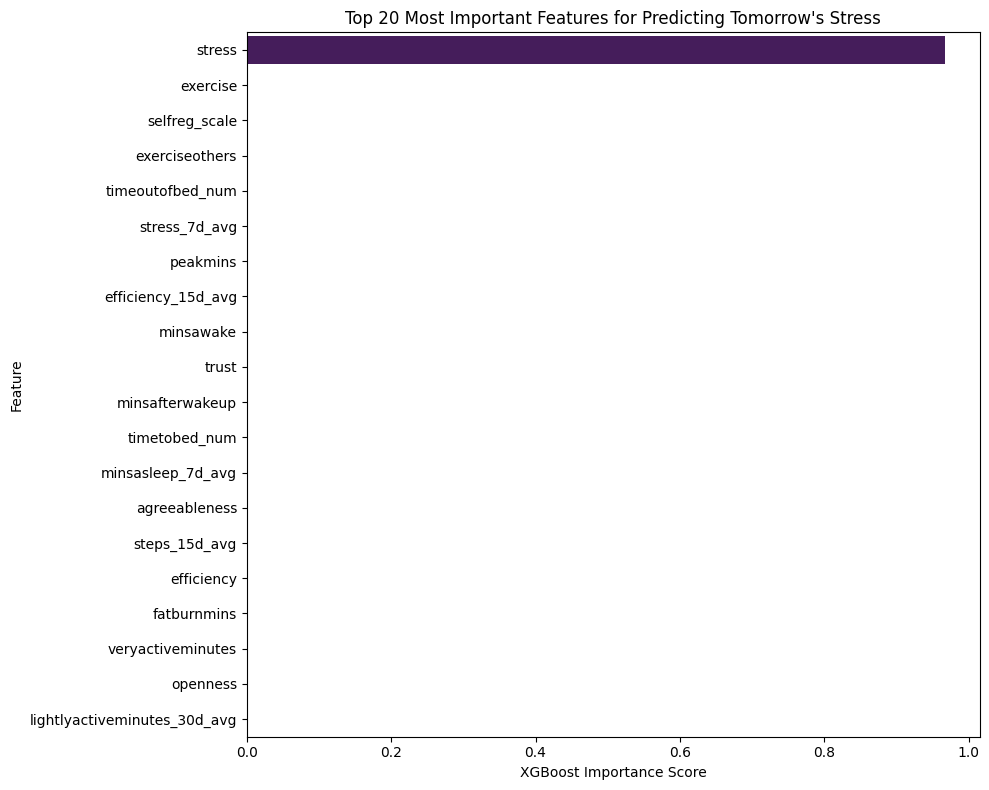

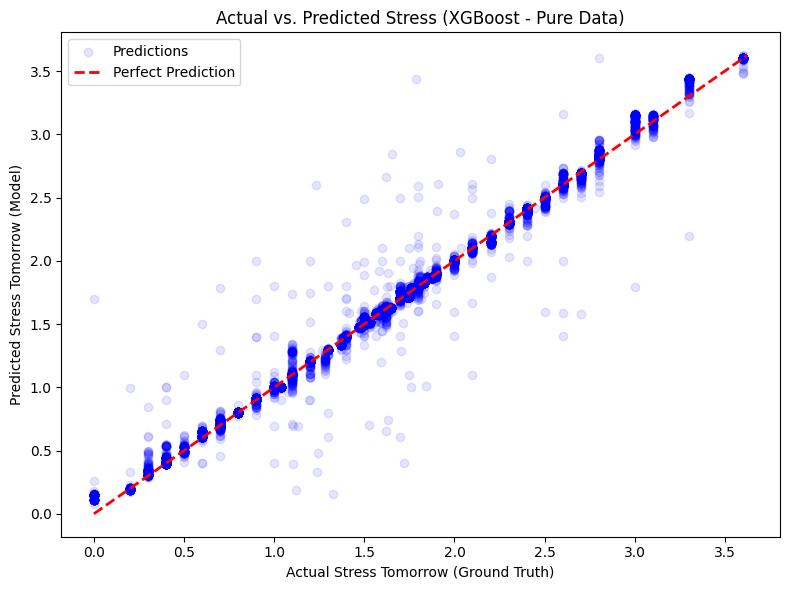

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Get the pure predictions from the test set
y_pred_pure = xgb_model_pure.predict(X_test_pure)

# ==========================================
# 1. FEATURE IMPORTANCE (What drove the predictions?)
# ==========================================
# Extract importances and map them to column names
importances = xgb_model_pure.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_pure.columns, 'Importance': importances})

# Sort and grab the top 20 most influential features
top_20_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title("Top 20 Most Important Features for Predicting Tomorrow's Stress")
plt.xlabel("XGBoost Importance Score")
plt.tight_layout()
plt.show()

# ==========================================
# 2. ACTUAL VS PREDICTED VISUALIZATION
# ==========================================
plt.figure(figsize=(8, 6))
# Plot the actual test values against the model's predictions
plt.scatter(y_test_pure, y_pred_pure, alpha=0.1, color='blue', label='Predictions')

# Draw a red dashed line representing "Perfect Accuracy" (y = x)
min_val = min(y_test_pure.min(), y_pred_pure.min())
max_val = max(y_test_pure.max(), y_pred_pure.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Stress (XGBoost - Pure Data)')
plt.xlabel('Actual Stress Tomorrow (Ground Truth)')
plt.ylabel('Predicted Stress Tomorrow (Model)')
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. FIX THE LEAKAGE: Identify all stress-related columns in X and drop them
leakage_cols = [col for col in X_pure.columns if 'stress' in col.lower()]
X_clean = X_pure.drop(columns=leakage_cols)

# 2. DEFINE THE MODALITIES (Surveys vs. Wearables)
survey_keywords = ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 
                   'openness', 'psqi', 'selsa', 'selfreg', 'exercise']
survey_cols = [col for col in X_clean.columns if any(kw in col.lower() for kw in survey_keywords)]
wearable_cols = [col for col in X_clean.columns if col not in survey_cols]

# 3. CREATE THE 3 FEATURE SETS
X_survey_only = X_clean[survey_cols]
X_wearable_only = X_clean[wearable_cols]
X_combined = X_clean

# 4. SPLIT THE DATA FOR ALL 3 EXPERIMENTS
X_train_surv, X_test_surv, y_train, y_test = train_test_split(X_survey_only, y_pure, test_size=0.2, random_state=42, shuffle=False)
X_train_wear, X_test_wear, _, _ = train_test_split(X_wearable_only, y_pure, test_size=0.2, random_state=42, shuffle=False)
X_train_comb, X_test_comb, _, _ = train_test_split(X_combined, y_pure, test_size=0.2, random_state=42, shuffle=False)

# 5. TRAIN AND EVALUATE ALL 3 MODELS (XGBoost & Random Forest)
print("Running Modality Ablation Study...\n")

# Define Random Forest parameters from the paper
rf_params = {
    'max_depth': 4, 
    'min_samples_leaf': 1, 
    'min_samples_split': 10, 
    'n_estimators': 5, 
    'random_state': 42, 
    'n_jobs': -1
}

# --- Model A: Surveys Only ---
xgb_surv = xgb.XGBRegressor(max_depth=3, n_estimators=157, learning_rate=0.2993, random_state=42, n_jobs=-1)
xgb_surv.fit(X_train_surv, y_train)
mae_xgb_surv = mean_absolute_error(y_test, xgb_surv.predict(X_test_surv))

rf_surv = RandomForestRegressor(**rf_params)
rf_surv.fit(X_train_surv, y_train)
mae_rf_surv = mean_absolute_error(y_test, rf_surv.predict(X_test_surv))

# --- Model B: Wearables Only ---
xgb_wear = xgb.XGBRegressor(max_depth=3, n_estimators=157, learning_rate=0.2993, random_state=42, n_jobs=-1)
xgb_wear.fit(X_train_wear, y_train)
mae_xgb_wear = mean_absolute_error(y_test, xgb_wear.predict(X_test_wear))

rf_wear = RandomForestRegressor(**rf_params)
rf_wear.fit(X_train_wear, y_train)
mae_rf_wear = mean_absolute_error(y_test, rf_wear.predict(X_test_wear))

# --- Model C: Combined ---
xgb_comb = xgb.XGBRegressor(max_depth=3, n_estimators=157, learning_rate=0.2993, random_state=42, n_jobs=-1)
xgb_comb.fit(X_train_comb, y_train)
mae_xgb_comb = mean_absolute_error(y_test, xgb_comb.predict(X_test_comb))

rf_comb = RandomForestRegressor(**rf_params)
rf_comb.fit(X_train_comb, y_train)
mae_rf_comb = mean_absolute_error(y_test, rf_comb.predict(X_test_comb))

# --- Print Results ---
print(f"1. SURVEYS ONLY   | XGBoost MAE: {mae_xgb_surv:.4f} | RF MAE: {mae_rf_surv:.4f}")
print(f"2. WEARABLES ONLY | XGBoost MAE: {mae_xgb_wear:.4f} | RF MAE: {mae_rf_wear:.4f}")
print(f"3. COMBINED DATA  | XGBoost MAE: {mae_xgb_comb:.4f} | RF MAE: {mae_rf_comb:.4f}")

Running Modality Ablation Study...

1. SURVEYS ONLY   | XGBoost MAE: 0.3836 | RF MAE: 0.4143
2. WEARABLES ONLY | XGBoost MAE: 0.4300 | RF MAE: 0.3824
3. COMBINED DATA  | XGBoost MAE: 0.4065 | RF MAE: 0.4019


C:\Users\yodit\AppData\Local\Temp\ipykernel_34688\837322306.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features_comb, palette='magma')


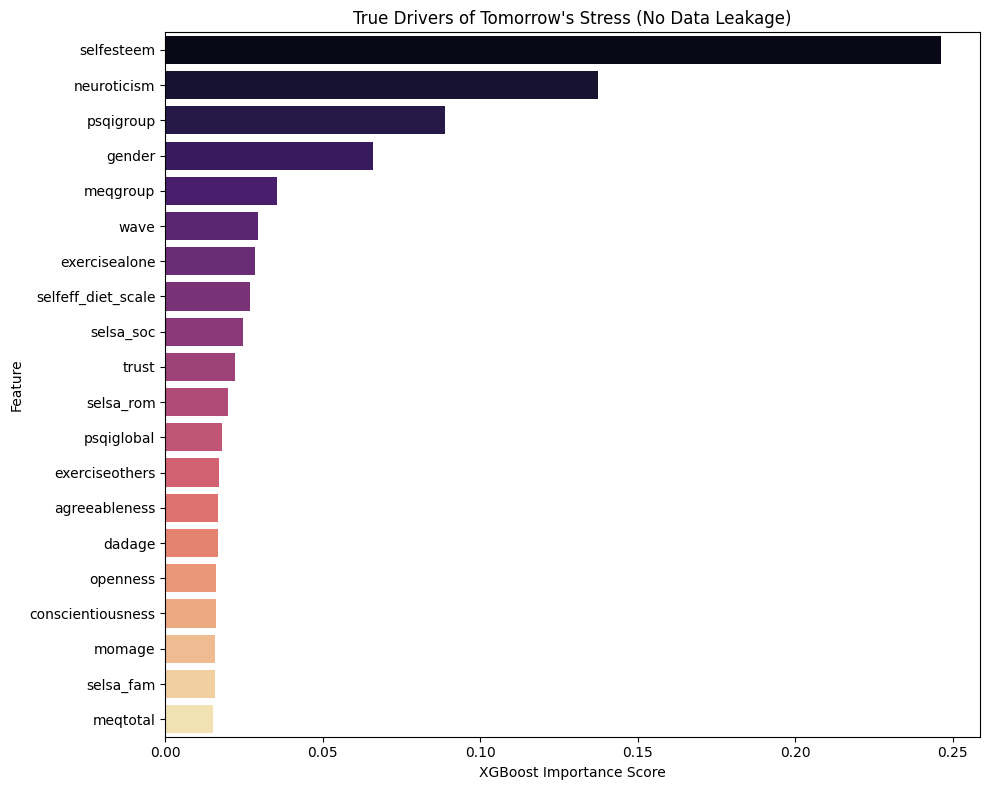

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract importances from your newly trained, honest Combined model
importances_comb = xgb_comb.feature_importances_

# 2. Create a DataFrame mapping the clean features to their importance scores
feature_imp_comb_df = pd.DataFrame({
    'Feature': X_combined.columns, 
    'Importance': importances_comb
})

# 3. Sort and grab the top 20 most influential features
top_20_features_comb = feature_imp_comb_df.sort_values(by='Importance', ascending=False).head(20)

# 4. Build the visualization
plt.figure(figsize=(10, 8))
# Using the 'magma' color palette this time to distinguish it from the old leaky chart
sns.barplot(x='Importance', y='Feature', data=top_20_features_comb, palette='magma')
plt.title("True Drivers of Tomorrow's Stress (No Data Leakage)")
plt.xlabel("XGBoost Importance Score")
plt.tight_layout()
plt.show()

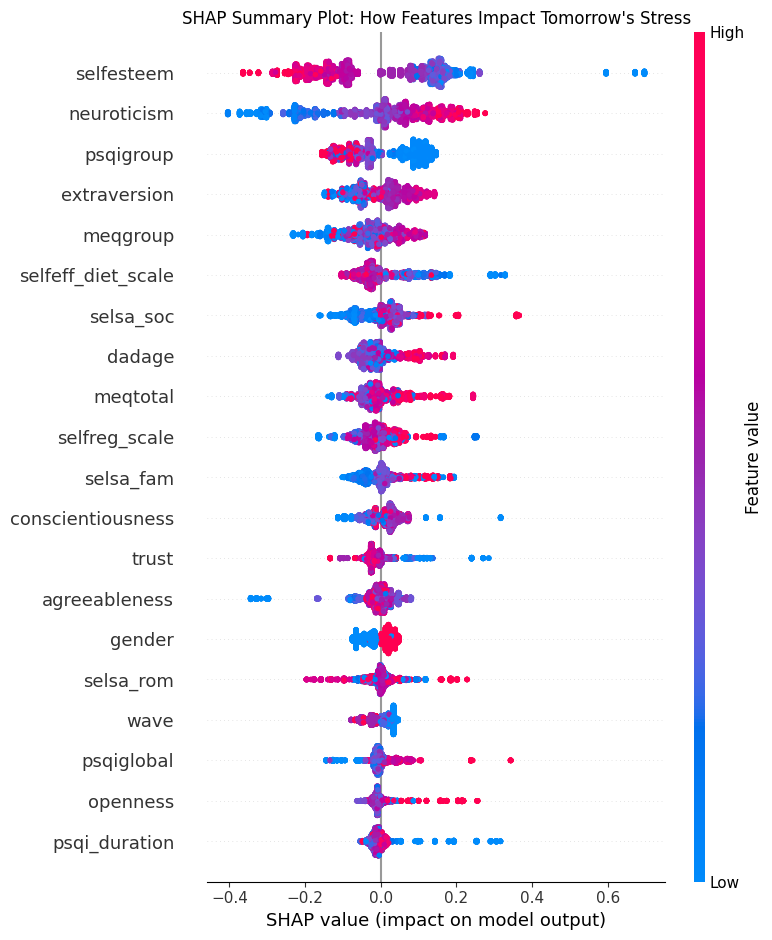

In [72]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer with your Combined XGBoost model
explainer = shap.TreeExplainer(xgb_comb)

# 2. Sample the test data to calculate SHAP values quickly (5,000 rows is plenty for a good chart)
X_shap = X_test_comb.sample(n=5000, random_state=42)

# 3. Calculate the SHAP values
shap_values = explainer.shap_values(X_shap)

# 4. Generate the SHAP Summary Plot
plt.title("SHAP Summary Plot: How Features Impact Tomorrow's Stress")
shap.summary_plot(shap_values, X_shap, max_display=20)

### Using Randomized Search


In [73]:
# from sklearn.model_selection import RandomizedSearchCV
# import xgboost as xgb
# import numpy as np

# print("Starting Hyperparameter Tuning for XGBoost (Combined Data)...")

# # 1. Define the grid of parameters we want to test
# param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [3, 4, 5, 6, 8],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'min_child_weight': [1, 3, 5, 7]
# }

# # 2. Initialize a fresh, empty XGBoost Regressor
# xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# # 3. Set up the Randomized Search
# # n_iter=20 means it will try 20 different random combinations of the parameters above
# # cv=3 means it will use 3-fold cross-validation to ensure it doesn't overfit
# random_search = RandomizedSearchCV(
#     estimator=xgb_base,
#     param_distributions=param_grid,
#     n_iter=20, 
#     scoring='neg_mean_absolute_error', # We want to minimize MAE
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# # 4. Fit the search to your Combined training data
# random_search.fit(X_train_comb, y_train)

# # 5. Extract the best model and test it
# best_xgb_comb = random_search.best_estimator_
# y_pred_tuned = best_xgb_comb.predict(X_test_comb)
# tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

# print("\n=== TUNING RESULTS ===")
# print(f"Old MAE (Paper's Params): 0.3869")
# print(f"New MAE (Tuned Params):   {tuned_mae:.4f}")
# print("\nBest Hyperparameters Found:")
# print(random_search.best_params_)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

print("Starting FAST Hyperparameter Tuning for XGBoost...")

# 1. A much smaller, faster grid
param_grid_fast = {
    'n_estimators': [100, 150, 200],       
    'max_depth': [3, 4, 5],                
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [3, 5]
}

# 2. Base model using 'hist' for massive speed improvements
xgb_base_fast = xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist')

# 3. Faster Randomized Search (10 combinations x 3 folds = 30 models)
random_search_fast = RandomizedSearchCV(
    estimator=xgb_base_fast,
    param_distributions=param_grid_fast,
    n_iter=10, 
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Fit the search to the combined data
random_search_fast.fit(X_train_comb, y_train)

# 5. Extract results
best_xgb_fast = random_search_fast.best_estimator_
tuned_mae_fast = mean_absolute_error(y_test, best_xgb_fast.predict(X_test_comb))

print("\n=== FAST TUNING RESULTS ===")
print(f"Old MAE (Paper's Params): 0.4065")
print(f"New MAE (Tuned Params):   {tuned_mae_fast:.4f}")
print("\nBest Parameters Found:")
print(random_search_fast.best_params_)

Starting FAST Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== FAST TUNING RESULTS ===
Old MAE (Paper's Params): 0.3869
New MAE (Tuned Params):   0.3666

Best Parameters Found:
{'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
